# Insurance Cost Prediction PRCP-1021

Submitted By: NASEEB KHAN

Course: (CDS)

# Problem Statement

The objective of this project is to analyze insurance customer data and build a machine learning model that predicts medical insurance charges based on customer attributes such as:
Age,
Gender,
BMI,
Number of children,
Smoking status,
Region.

The final goal is to compare multiple ML algorithms and select the best model for production deployment.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
# Evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# Load Dataset

In [2]:
df=pd.read_csv("insurance(1).csv")

In [3]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
# This project is a Regression Machine Learning Project because the target column charges is continuous numerical data.

In [5]:
df.region

0       southwest
1       southeast
2       southeast
3       northwest
4       northwest
          ...    
1333    northwest
1334    northeast
1335    southeast
1336    southwest
1337    northwest
Name: region, Length: 1338, dtype: object

In [6]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [7]:
df.shape

(1338, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Exploratory Data Analysis (EDA)

# Distribution of Charges

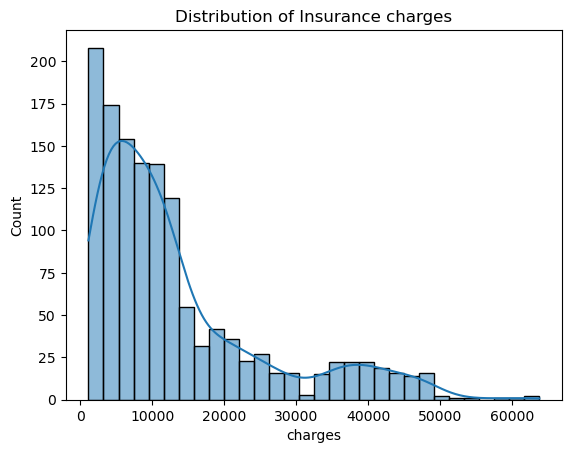

In [11]:
sns.histplot(df['charges'],kde=True)
plt.title("Distribution of Insurance charges")
plt.show()

# Age vs Charges

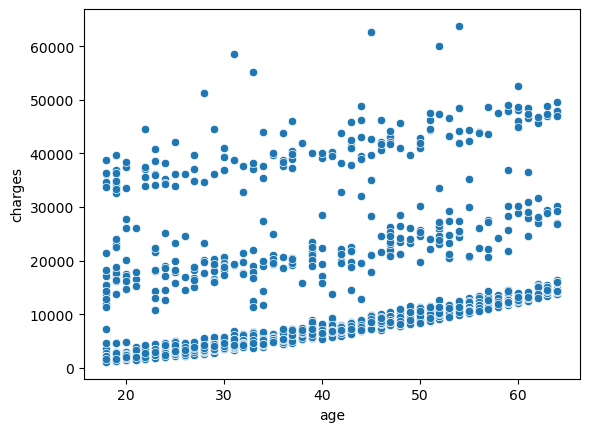

In [12]:
sns.scatterplot(x='age', y='charges', data=df)
plt.show()

# BMI vs Charges

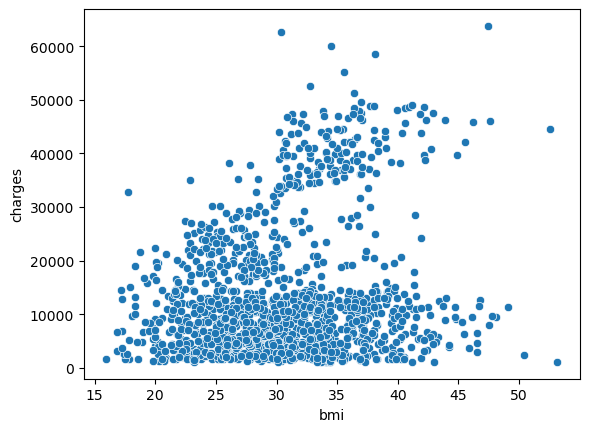

In [13]:
sns.scatterplot(x='bmi',y='charges',data=df)
plt.show()

# Smoker vs Charges

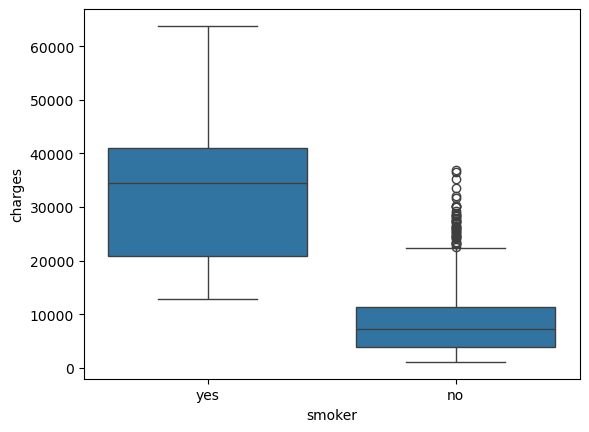

In [14]:
sns.boxplot(x='smoker',y='charges', data=df)
plt.show()

# Region Count

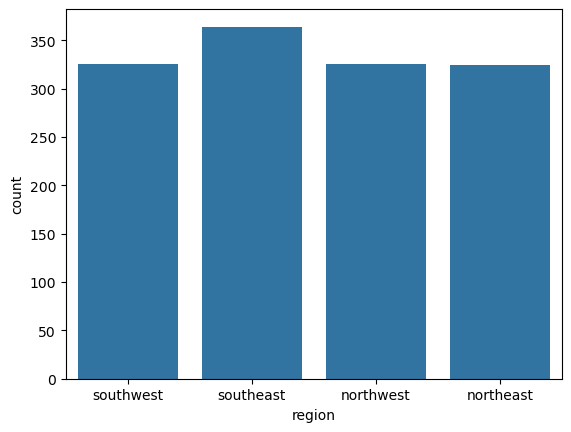

In [15]:
sns.countplot(x='region',data=df)
plt.show()

# Correlation Heatmap

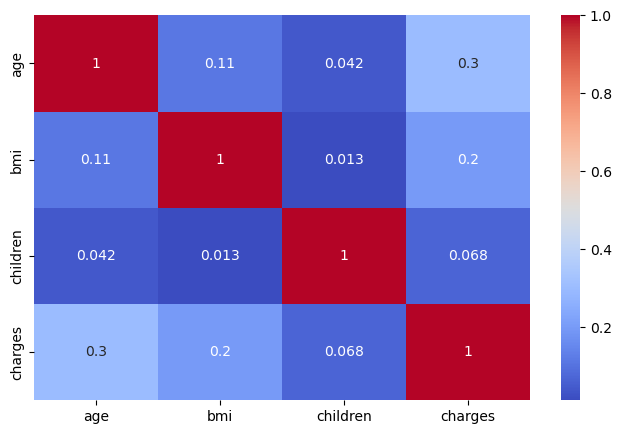

In [16]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Observations from EDA

# Data Preprocessing

In [17]:
 # Convert Categorical Columns into Numerical
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [19]:
# Define Input and Output Variables
X=df.drop(['charges'], axis=1)
y=df['charges']

In [20]:
#Train-Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Model Building

# Linear Regression

In [21]:
lr=LinearRegression()
lr.fit(X_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
lr_pred=lr.predict(X_test)

In [23]:
print("Linear Regression")

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression
MAE: 4186.5088983664355
MSE: 33635210.43117841
RMSE: 5799.587091438356
R2 Score: 0.7833463107364538


# Decision Tree

In [24]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [25]:
dt_pred=dt.predict(X_test)

In [26]:
print("Decision Tree")

print("MAE:", mean_absolute_error(y_test, dt_pred))
print("MSE:", mean_squared_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score:", r2_score(y_test, dt_pred))

Decision Tree
MAE: 3154.705668541045
MSE: 49003243.60682007
RMSE: 7000.231682367382
R2 Score: 0.6843565603663775


# Random Forest Regressor

In [27]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
rf_pred=rf.predict(X_test)

In [29]:
print("Random Forest")

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest
MAE: 2533.674643617756
MSE: 21073365.415079337
RMSE: 4590.5735387944
R2 Score: 0.8642606273649586


# XGBoost Regressor

In [30]:
!pip install xgboost

In [31]:
#xgb=XGBRegressor()
xgb=XGBRegressor(     
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4
)
xgb.fit(X_train,y_train)

#Hyperparameter Tuning Improved
# This reduced prediction error and increased the R2 Score
#Learning capability
#Generalization
#Reduced overfitting

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
xgb_pred=xgb.predict(X_test)

In [33]:
print("XGBoost Regressor")
print("MAE:",mean_absolute_error(y_test,xgb_pred))
print("MSE:",mean_squared_error(y_test,xgb_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,xgb_pred)))
print("R2 Score:",r2_score(y_test,xgb_pred))

XGBoost Regressor
MAE: 2361.4582481684934
MSE: 18435495.95112111
RMSE: 4293.657642514259
R2 Score: 0.881251873854454


# Model Comparison Report

In [34]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.783346
1,Decision Tree,0.684357
2,Random Forest,0.864261
3,XGBoost,0.881252


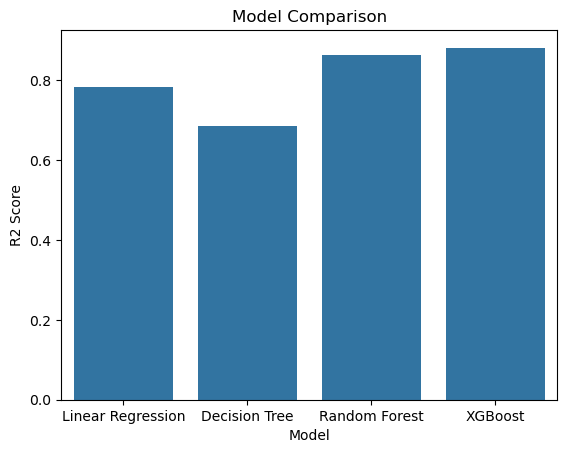

In [35]:
sns.barplot(x='Model', y='R2 Score', data=results)
plt.title("Model Comparison")
plt.show()

# Best Model for Production

Among all machine learning models, XGBoost Regressor achieved the highest R2 Score and lowest prediction error.

Therefore, XGBoost is selected as the best model for production deployment because it provides better accuracy and generalization performance.

After comparing multiple regression algorithms, the tuned XGBoost Regressor achieved the highest R2 Score of 0.881, outperforming Random Forest, Decision Tree, and Linear Regression models.

Hyperparameter tuning significantly improved prediction performance by optimizing model complexity and learning behavior. Therefore, the tuned XGBoost model was selected as the final production model for insurance cost prediction.



# Challenges Faced

# Final Conclusion




This project successfully analyzed insurance customer data and developed machine learning models to predict insurance charges.

Different regression algorithms were implemented and evaluated using R2 Score, MAE, RMSE, and MSE metrics.

Among all models, XGBoost performed best and was selected as the final production model because of its higher accuracy and lower error.

XGBoost model achieved the highest R2 Score (0.8812), making it the best-performing model for predicting insurance charges.
    